In [3]:
import pandas as pd
import re
import emoji
import numpy as np
import swifter
import nltk
d=pd.read_csv("raw_tweets_text.csv",nrows=1500000)
d=d.drop_duplicates(subset="text")
d.sample(10)

,id,text
186077,768114245527416832,RT @PurelyFootball: What a difference 3 years ...
1337865,784310093235924992,Discover who visits your Twitter profile here:...
659809,769324612614225920,RT @DailyRasp: @robertmarles @themadsloth#Canp...
953729,781461686880460804,I have gone full Halloween. https://t.co/ctSbX...
739515,769516028044808193,RT @kelly_kmeyer: Reward for a hard week of wo...
1302231,784062557984141312,WHOLESALE LOT LARIMAR ROYAL RUBY CORAL 20 PCS ...
787424,780346190760206336,Hot! New White/ivory Wedding dress Bridal Gown...
1397498,784743973009166336,Buy a comfort bra &amp; we'll donate R5 to the...
1482735,785367296927608833,Scottish government backs Heathrow expansion h...
1366375,784488011429974016,#news #iphone 7 will probably have the same si...


In [4]:
# Example slang dictionary
slang_dict = {
    "gr8": "great",
    "lol": "laugh",
    "omg": "oh my god",
    "btw": "by the way",
    "idk": "I don't know",
    "smh": "shaking my head"
}

# Sarcasm triggers
sarcasm_triggers = ["yeah right", "sure", "as if", "lol", "totally", "not really"]

#Clean text
def clean_tweet(text):
    if not isinstance(text,str):
        return ""
    text=text.lower() #lower text
    text=re.sub(r"https?://\S+|www\.\S+","",text) #remove URLs
    text=re.sub(r"@\w+","",text) #remove mention
    text=re.sub(r"\brt\b","",text) #remove retweet
    text=re.sub(r"#(\w+)",r"\1",text) # remove hashtag
    text=re.sub(r"[\n\t]","",text) # remove newline and tab
    text=re.sub(r"[^\w\s]"," ",text)
    text=re.sub(r"\d+","",text) #remove numbers
    text=re.sub(r"(.)\1{2,}",r"\1\1",text) #limit repeated characters to 2

    #Transform emoticons to tokens
    emoticon_dict = {":)": "emoji_smile", ":-)": "emoji_smile",
                     ":(": "emoji_sad", ":-(": "emoji_sad",
                     ":D": "emoji_laugh", ";)": "emoji_wink"}
    
    for emo, token in emoticon_dict.items():
        text=text.replace(emo, f" {token} ")
        
    for slang,word in slang_dict.items():
        text=re.sub(rf"\b{slang}\b",word,text)
    return text.strip()

#Transform emoji in token
def demojize_text(text):
    text=emoji.demojize(text,language='en')
    text=re.sub(r":([a-z_]+):",r" emoji_\1",text)
    return text.strip()

def extract_emojis(text):
    return [char for char in text if char in emoji.EMOJI_DATA]
d["emojis"]=d["text"].swifter.apply(extract_emojis)
d["demojize"]=d["text"].swifter.apply(demojize_text)
d["text_clean"]=d["text"].swifter.apply(clean_tweet)

d.sample(10)

Pandas Apply: 100%|██████████| 1267062/1267062 [01:01<00:00, 20537.51it/s]


,id,text,emojis,demojize,text_clean
692773,769395940922753024,RT @MikeMotyka: It gets better every year ⚪️⚪️...,"[⚪, ⚪]",RT @MikeMotyka: It gets better every year emo...,it gets better every year leydenpride
1454280,785166737893363712,The holy trinity 💜💜💜 https://t.co/kMmzwCiYuq,"[💜, 💜, 💜]",The holy trinity emoji_purple_heart emoji_pur...,the holy trinity
1450297,785142641629417473,Been a busy morning @CLTMotorSpdwy &amp; it's ...,[],Been a busy morning @CLTMotorSpdwy &amp; it's ...,been a busy morning amp it s finally time to...
916774,781192379000844288,We're proud to welcome certified #prosthetist ...,[],We're proud to welcome certified #prosthetist ...,we re proud to welcome certified prosthetist c...
952056,781449716341018624,"Imaging of Diseases of the Chest, 4e https://t...",[],"Imaging of Diseases of the Chest, 4e https://t...",imaging of diseases of the chest e
1236867,783614350472818688,Jiyong invented finger heart since 1995 😂😂😂 ht...,"[😂, 😂, 😂]",Jiyong invented finger heart since 1995 emoji...,jiyong invented finger heart since
712163,769446553597673472,RT @RoseH_Official: Niall will be playing in t...,[],RT @RoseH_Official: Niall will be playing in t...,niall will be playing in the northern ireland ...
504097,769011692370030592,"thank you for the memories, but u suck for lea...",[],"thank you for the memories, but u suck for lea...",thank you for the memories but u suck for lea...
967010,781533233313832960,"Stephen Hawking, English Physicist (January 8,...",[],"Stephen Hawking, English Physicist (January 8,...",stephen hawking english physicist january
420264,768659094005624834,"RT @brianna__mahone: Last day of summer, last ...",[😭],"RT @brianna__mahone: Last day of summer, last ...",last day of summer last day without makeup r...


In [5]:
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords,wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

#Setup NLTK
tokenizer=TweetTokenizer()
negation_words={'not','no','never','neither','nor'}
stopwords_set=set(stopwords.words('english'))-negation_words
lemmatizer=WordNetLemmatizer()

#Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'): 
        return wordnet.NOUN
    elif tag.startswith('R'): 
        return wordnet.ADV
    else:
        return wordnet.NOUN #Default

def lemmatize_tokens(tokens):
    tagged_tokens=pos_tag(tokens)
    final=[]
    negation_flag=False
    for word, tag in tagged_tokens:
        if(word.isalpha() and word.lower()) not in stopwords_set:
            lemma=lemmatizer.lemmatize(word,get_wordnet_pos(tag))
            if word.lower() in negation_words:
                negation_flag=True
                final.append(lemma)
            else:
                if negation_flag:
                    final.append("NOT_"+lemma)
                else:
                    final.append(lemma)
            if word.startswith("emoji_"):
                negation_flag=False
                
    return final

def tokenize_lemmatize(text):
    tokens=tokenizer.tokenize(text)
    return lemmatize_tokens(tokens)
d["final_tokens"]=d["text_clean"].swifter.apply(tokenize_lemmatize)



Pandas Apply: 100%|██████████| 1267062/1267062 [13:24<00:00, 1574.38it/s]


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB,MultinomialNB
from sklearn.metrics import classification_report,accuracy_score
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack

sia=SentimentIntensityAnalyzer()#Inizialize VADER sentiment analyzer

#Function to convert VADER compound score to labels
def vader_label(score):
    if score>0:
        return "Positive"
    elif score<0:
        return "Negative"
    else:
        return "Neutral"

def vader_label2(text_score,emoji_score,alpha=0.5):
    final_score=text_score+alpha*emoji_score
    if final_score>0:
        return "Positive"
    elif final_score<0:
        return "Negative"
    else:
        return "Neutral"
df_with_emoji=d.copy()
#Calculate emoji_score using VADER
df_with_emoji["emoji_score"]=df_with_emoji["emojis"].swifter.apply(lambda x: sia.polarity_scores(str(x))['compound'])
df_with_emoji["text_score"]=df_with_emoji["text_clean"].swifter.apply(lambda x: sia.polarity_scores(str(x))['compound'])
#df_with_emoji["sentiment"]=df_with_emoji["emoji_score"].swifter.apply(vader_label) #Assign sentiment label based on emoji_score
df_with_emoji["sentiment"] = df_with_emoji.swifter.apply(lambda row: vader_label2(row["text_score"], row["emoji_score"]), axis=1)

print("Distribuzione sentiment:", df_with_emoji["sentiment"].value_counts())

#Prepare Features & Target
X_test=df_with_emoji["final_tokens"].apply(lambda t: " ".join(t)) #Join tokens into string
X_extra=df_with_emoji["emoji_score"].values.reshape(-1,1) #Emoji score as numeric feature
y=df_with_emoji["sentiment"] #Target sentiment

#Train/test split
X_train_text, X_test_text, X_train_extra,X_test_extra,y_train,y_test=train_test_split(X_test,X_extra,y,test_size=0.2,random_state=42,stratify=y)

#TF-IDF
tfidf=TfidfVectorizer(ngram_range=(1,3),min_df=3,max_df=0.8,sublinear_tf=True) #Consider unigrams to n-grams, ignore rare terms (min_df), ignore very common terms (max_df) and 
#apply logarithmic scaling to term frequency
X_train_tfidf=tfidf.fit_transform(X_train_text)
X_test_tfidf=tfidf.transform(X_test_text)

#Scaling emoji_score between 0 and 1
scaler=MinMaxScaler()
X_train_extra_scaled=scaler.fit_transform(X_train_extra)
X_test_extra_scaled=scaler.transform(X_test_extra)

X_train_final=hstack([X_train_tfidf,X_train_extra_scaled])
X_test_final=hstack([X_test_tfidf,X_test_extra_scaled])



Pandas Apply: 100%|██████████| 1267062/1267062 [00:05<00:00, 213760.50it/s]


Distribuzione sentiment: sentiment
Positive    545468
Neutral     536462
Negative    185132
Name: count, dtype: int64
Global Accuracy with MultinomialNB: 0.85

              precision    recall  f1-score   support

    Negative       0.87      0.54      0.67     37026
     Neutral       0.87      0.90      0.88    107293
    Positive       0.83      0.91      0.87    109094

    accuracy                           0.85    253413
   macro avg       0.86      0.79      0.81    253413
weighted avg       0.86      0.85      0.85    253413



Global Accuracy with MultinomialNB: 0.85

              precision    recall  f1-score   support

    Negative       0.87      0.54      0.67     37026
     Neutral       0.87      0.90      0.88    107293
    Positive       0.83      0.91      0.87    109094

    accuracy                           0.85    253413
   macro avg       0.86      0.79      0.81    253413
weighted avg       0.86      0.85      0.85    253413



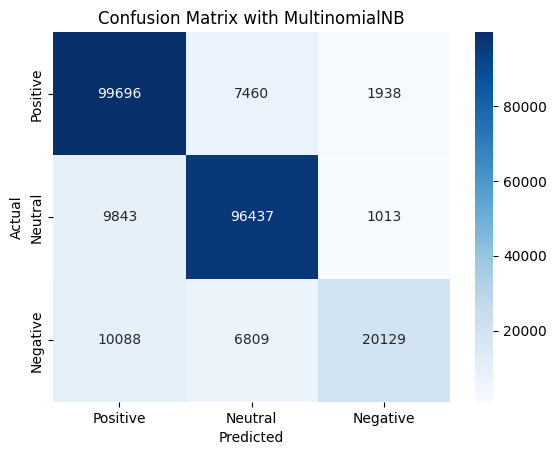

In [ ]:
#Test usign MultinomialNB - Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Train Multinomial Naive Bayes classifier with Smoothing Laplace (alpha=1)
model=MultinomialNB(alpha=1)
model.fit(X_train_final,y_train)
y_predMultinomial=model.predict(X_test_final) #Predict and test

print(f"Global Accuracy with MultinomialNB: {accuracy_score(y_test,y_predMultinomial):.2f}\n")
print(classification_report(y_test,y_predMultinomial))
cm=confusion_matrix(y_test,y_predMultinomial,labels=["Positive","Neutral","Negative"])
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with MultinomialNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Global Accuracy with MultinomialNB after Oversampling: 0.84

              precision    recall  f1-score   support

    Negative       0.58      0.89      0.70     37026
     Neutral       0.91      0.82      0.86    107293
    Positive       0.92      0.84      0.88    109094

    accuracy                           0.84    253413
   macro avg       0.80      0.85      0.81    253413
weighted avg       0.87      0.84      0.85    253413



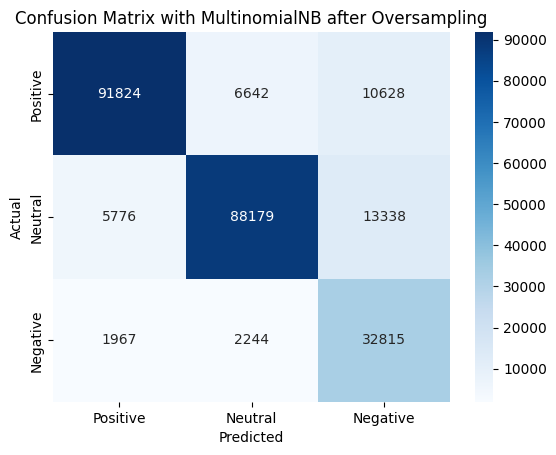

In [16]:
#Using Oversampling for MultinomialNB
from imblearn.over_sampling import RandomOverSampler    
ros=RandomOverSampler(random_state=42)
X_train_res,y_train_res=ros.fit_resample(X_train_final,y_train)

multinomial2=MultinomialNB(alpha=1)
multinomial2.fit(X_train_res,y_train_res)

y_predMultinomial_res=multinomial2.predict(X_test_final)
print(f"Global Accuracy with MultinomialNB after Oversampling: {accuracy_score(y_test,y_predMultinomial_res):.2f}\n")
print(classification_report(y_test,y_predMultinomial_res))
cm_after_oversampling=confusion_matrix(y_test,y_predMultinomial_res,labels=["Positive","Neutral","Negative"])
sns.heatmap(cm_after_oversampling,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with MultinomialNB after Oversampling")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Global Accuracy with ComplementNB: 0.86

              precision    recall  f1-score   support

    Negative       0.71      0.83      0.76     37026
     Neutral       0.87      0.86      0.87    107293
    Positive       0.91      0.86      0.89    109094

    accuracy                           0.86    253413
   macro avg       0.83      0.85      0.84    253413
weighted avg       0.86      0.86      0.86    253413



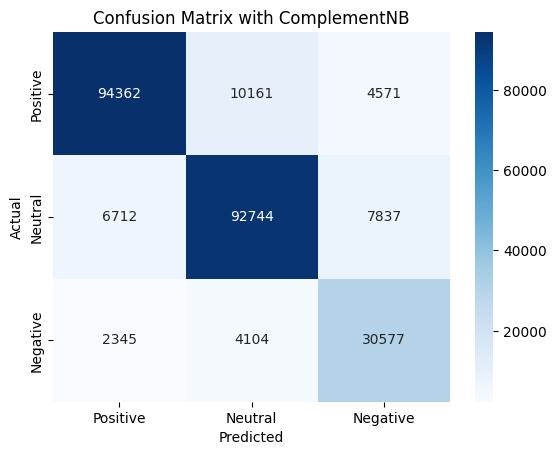

In [ ]:
#Test using ComplementNB
model2=ComplementNB(alpha=1) #Using Laplace smoothing
model2.fit(X_train_final,y_train)
y_predComplement=model2.predict(X_test_final)
print(f"Global Accuracy with ComplementNB: {accuracy_score(y_test,y_predComplement):.2f}\n")
print(classification_report(y_test,y_predComplement))

cmw=confusion_matrix(y_test,y_predComplement,labels=["Positive","Neutral","Negative"])
sns.heatmap(cmw,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with ComplementNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Global Accuracy with LogisticRegression: 0.95

              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89     37026
     Neutral       0.95      0.97      0.96    107293
    Positive       0.97      0.94      0.96    109094

    accuracy                           0.95    253413
   macro avg       0.94      0.94      0.94    253413
weighted avg       0.95      0.95      0.95    253413



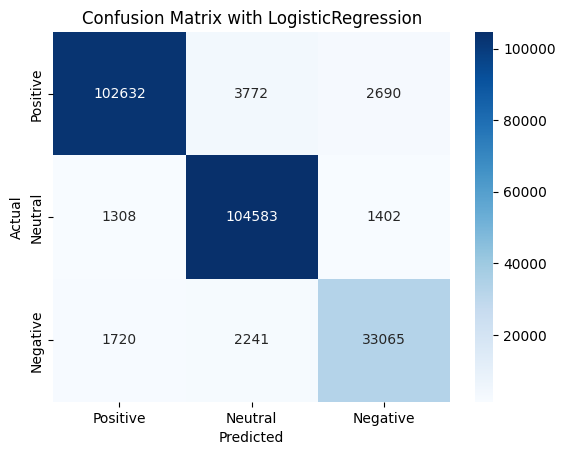

In [9]:
#Test using LogisticRegression
from sklearn.linear_model import LogisticRegression

modelLogistic=LogisticRegression(max_iter=1000,solver='liblinear',class_weight='balanced')
modelLogistic.fit(X_train_final,y_train)

y_predRegression=modelLogistic.predict(X_test_final)

print(f"Global Accuracy with LogisticRegression: {accuracy_score(y_test,y_predRegression):.2f}\n")
print(classification_report(y_test,y_predRegression))

cmr=confusion_matrix(y_test,y_predRegression,labels=["Positive","Neutral","Negative"])
sns.heatmap(cmr,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with LogisticRegression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Global Accuracy with Logistic Regression after Oversampling: 0.95

              precision    recall  f1-score   support

    Negative       0.87      0.93      0.90     37026
     Neutral       0.95      0.97      0.96    107293
    Positive       0.98      0.94      0.96    109094

    accuracy                           0.95    253413
   macro avg       0.93      0.95      0.94    253413
weighted avg       0.95      0.95      0.95    253413



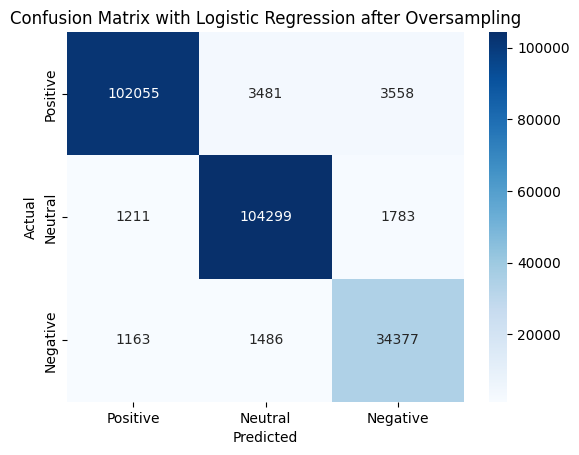

In [18]:
#Using Oversampling for MultinomialNB
from imblearn.over_sampling import RandomOverSampler    
ros=RandomOverSampler(random_state=42)
X_train_res,y_train_res=ros.fit_resample(X_train_final,y_train)

multinomial2=LogisticRegression(max_iter=1000,solver='liblinear',class_weight='balanced')
multinomial2.fit(X_train_res,y_train_res)

y_predMultinomial_res=multinomial2.predict(X_test_final)
print(f"Global Accuracy with Logistic Regression after Oversampling: {accuracy_score(y_test,y_predMultinomial_res):.2f}\n")
print(classification_report(y_test,y_predMultinomial_res))
cm_after_oversampling=confusion_matrix(y_test,y_predMultinomial_res,labels=["Positive","Neutral","Negative"])
sns.heatmap(cm_after_oversampling,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with Logistic Regression after Oversampling")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()